# Phân tích dữ liệu hai biến trên dữ liệu về chim cánh cụt (penguins-size)

# Giới thiệu
Bộ dữ liệu Palmer Penguins là một tập dữ liệu nổi tiếng trong lĩnh vực phân tích và trực quan hóa dữ liệu, được thu thập tại quần đảo Palmer, Nam Cực. Bộ dữ liệu này được xem là một thay thế thân thiện và tự nhiên hơn cho bộ dữ liệu Iris trong việc học và thực hành các kỹ thuật phân tích dữ liệu hai biến hoặc đa biến.

# Thông tin tổng quan
- Nguồn dữ liệu: được công bố bởi Dr. Kristen Gorman và nhóm nghiên cứu của Palmer Station, Antarctica LTER (Long Term Ecological Research Network).
- Mục đích: hỗ trợ phân tích sinh học, thống kê, và học máy — cụ thể là nghiên cứu về sự khác biệt hình thái giữa các loài chim cánh cụt theo giới tính, loài và vị trí địa lý.
- Bộ dữ liệu chứa thông tin về kích thước và đặc điểm cơ thể của ba loài chim cánh cụt: Adelie, Gentoo, Chinstrap

### 1. Import thư viện và chuẩn bị dữ liệu phân tích

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Đọc dữ liệu chim cánh cụt
penguins_data = pd.read_csv("penguins_size.csv")
# Lọc các cột cần thiết
penguins_data = penguins_data[['species', 'sex', 'culmen_length_mm','body_mass_g']]
# Xóa các dòng bị thiếu dữ liệu
penguins_data = penguins_data.dropna()
penguins_data.head()

,species,sex,culmen_length_mm,body_mass_g
0,Adelie,MALE,39.1,3750.0
1,Adelie,FEMALE,39.5,3800.0
2,Adelie,FEMALE,40.3,3250.0
4,Adelie,FEMALE,36.7,3450.0
5,Adelie,MALE,39.3,3650.0


| Tên cột             | Mô tả                                        | Kiểu dữ liệu | Đơn vị |
| ------------------- | -------------------------------------------- | ------------ | ------ |
| `species`           | Loài chim cánh cụt                           | Categorical  | —      |
| `island`            | Hòn đảo sinh sống (Biscoe, Dream, Torgersen) | Categorical  | —      |
| `culmen_length_mm`  | Chiều dài mỏ (culmen)                        | Numeric      | mm     |
| `culmen_depth_mm`   | Độ sâu mỏ                                    | Numeric      | mm     |
| `flipper_length_mm` | Chiều dài cánh (vây bơi)                     | Numeric      | mm     |
| `body_mass_g`       | Khối lượng cơ thể                            | Numeric      | g      |
| `sex`               | Giới tính (Male/Female)                      | Categorical  | —      |


### 2. Phân tích dữ liệu 2 biến dựa vào phương pháp scatterplot

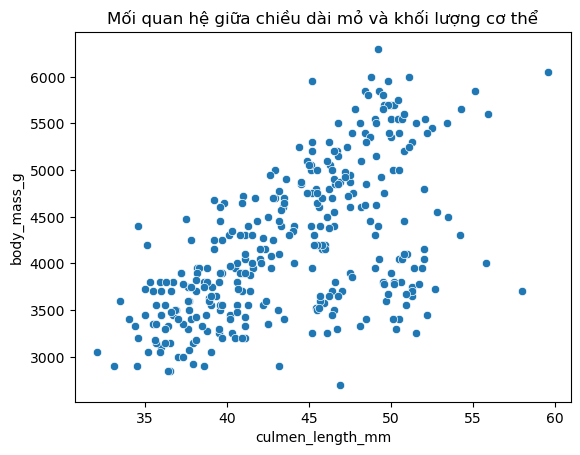

In [5]:
# Case 1: Basic scatterplot
sns.scatterplot(data=penguins_data, 
                x='culmen_length_mm', 
                y='body_mass_g')
plt.title("Mối quan hệ giữa chiều dài mỏ và khối lượng cơ thể")
plt.show()

### Nhận xét
Biểu đồ: Mối quan hệ giữa chiều dài mỏ (culmen_length_mm) và khối lượng cơ thể (body_mass_g):
- Biểu đồ thể hiện mối tương quan dương rõ rệt giữa hai biến:
→ Khi chiều dài mỏ tăng, khối lượng cơ thể của chim cánh cụt cũng có xu hướng tăng.
- Các điểm dữ liệu phân bố tương đối chặt chẽ theo một đường xiên hướng lên trên bên phải, cho thấy mối liên hệ khá mạnh giữa hai đặc trưng này.
- Một số điểm rải rác ở hai đầu (mỏ ngắn nhưng nặng hoặc mỏ dài nhưng nhẹ) cho thấy sự khác biệt giữa các loài chim cánh cụt hoặc sai số tự nhiên trong phép đo.

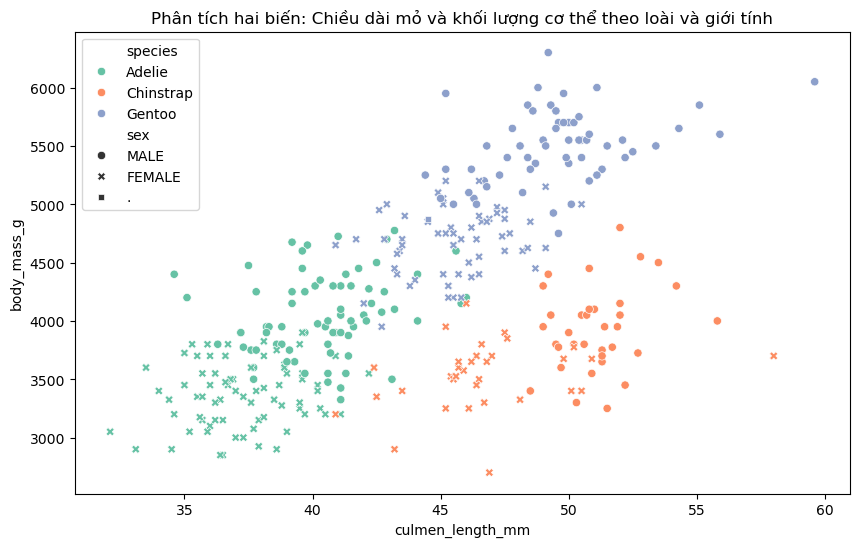

In [8]:
#Case 2: Advanced scatterplot có phân biệt loài
plt.figure(figsize=(10,6))
sns.scatterplot(data=penguins_data, 
                x='culmen_length_mm', 
                y='body_mass_g',
                hue='species',
                style='sex',
                palette='Set2')
plt.title("Phân tích hai biến: Chiều dài mỏ và khối lượng cơ thể theo loài và giới tính")
plt.show()

### Nhận xét
Biểu đồ: Chiều dài mỏ (culmen_length_mm) và khối lượng cơ thể (body_mass_g) theo loài và giới tính chim cánh cụt:
- Xu hướng chung vẫn là chiều dài mỏ tăng thì khối lượng cơ thể cũng tăng, thể hiện tương quan dương mạnh mẽ.
- Phân loại theo loài giúp dễ dàng nhận thấy Gentoo là loài to lớn nhất, còn Adelie nhỏ nhất.

- Giới tính cũng có tác động, với chim đực thường có khối lượng lớn hơn chim cái trong cùng một loài.

### 3. Phân tích 2 biến dựa vào bảng crosstab/two-way

In [11]:
pd.crosstab(index=penguins_data['species'], columns=penguins_data['sex'])

sex,.,FEMALE,MALE
species,,,
Adelie,0,73,73
Chinstrap,0,34,34
Gentoo,1,58,61


### Nhận xét
Bảng crosstab cung cấp cái nhìn tổng quan và rõ ràng về phân bố giới tính giữa các loài chim cánh cụt.
→ Cả ba loài (Adelie, Chinstrap, Gentoo) đều có tỷ lệ giới tính gần 1:1, điều này giúp đảm bảo tính khách quan khi thực hiện các phân tích tiếp theo như kiểm định sự khác biệt giữa giới tính hay huấn luyện mô hình dự đoán.

### 4. Phân tích 2 biến sử dụng pivot_table

In [ ]:
pd.pivot_table(penguins_data, values='culmen_length_mm',index='species', aggfunc=np.mean)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6336\4042239067.py:1: FutureWarning: The provided callable <function mean at 0x00000227FFF180E0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(penguins_data, values='culmen_length_mm',


,culmen_length_mm
species,
Adelie,38.823973
Chinstrap,48.833824
Gentoo,47.542500


### Nhận xét
- Loài Chinstrap có chiều dài mỏ trung bình lớn nhất, tiếp theo là Gentoo, và Adelie có mỏ ngắn nhất.
- Sự khác biệt này gợi ý rằng chiều dài mỏ có thể là đặc trưng quan trọng để phân biệt các loài chim cánh cụt trong bộ dữ liệu.

### 5. Phân tích 2 biến bằng Pairplot

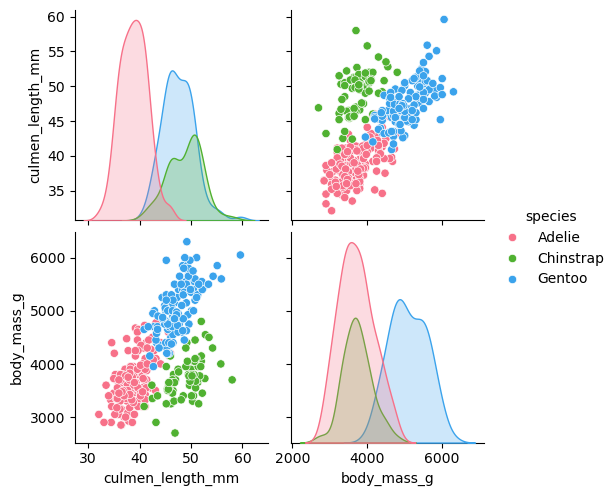

In [14]:
sns.pairplot(data=penguins_data, hue='species', palette='husl')
plt.show()

### Nhận xét
Biểu đồ Pairplot:
- Cả hai đặc trưng chiều dài mỏ và khối lượng cơ thể đều là yếu tố phân loại loài chim rất mạnh.
- Gentoo nổi bật với khối lượng cơ thể lớn nhất.
- Chinstrap có mỏ dài nhất.
- Adelie có mỏ ngắn và trọng lượng nhẹ nhất.

 ### 6. Phân tích mối quan hệ hai biến bằng scikit-learn

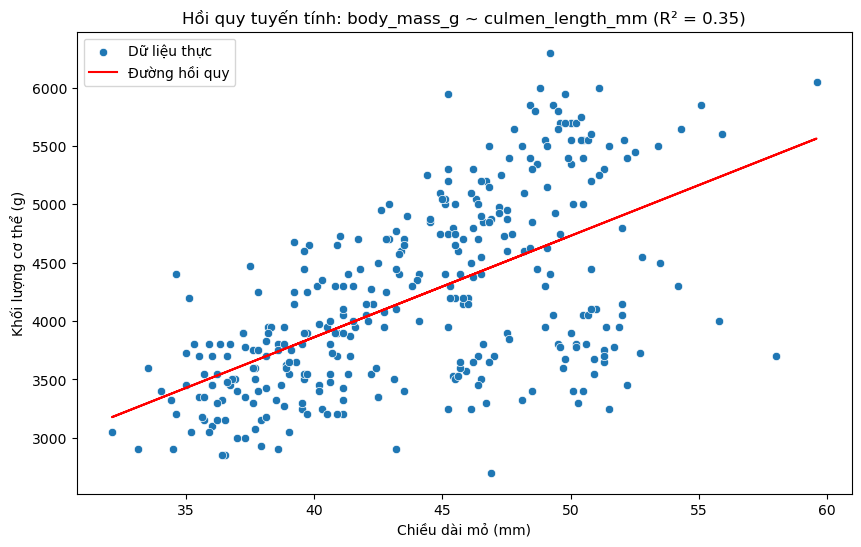

In [15]:
# Tạo mô hình hồi quy tuyến tính
model = LinearRegression()

# Lấy biến đầu vào (X) và đầu ra (y)
X = penguins_data[['culmen_length_mm']]
y = penguins_data['body_mass_g']

# Huấn luyện mô hình
model.fit(X, y)

# Dự đoán
y_pred = model.predict(X)

# Tính hệ số xác định R²
r2 = r2_score(y, y_pred)

# Hiển thị kết quả
plt.figure(figsize=(10,6))
sns.scatterplot(x=X['culmen_length_mm'], y=y, label='Dữ liệu thực')
plt.plot(X, y_pred, color='red', label='Đường hồi quy')
plt.title(f"Hồi quy tuyến tính: body_mass_g ~ culmen_length_mm (R² = {r2:.2f})")
plt.xlabel('Chiều dài mỏ (mm)')
plt.ylabel('Khối lượng cơ thể (g)')
plt.legend()
plt.show()

### Nhận xét
1. Mối quan hệ giữa hai biến:

- Biểu đồ thể hiện mối tương quan dương giữa chiều dài mỏ (culmen_length_mm) và khối lượng cơ thể (body_mass_g) của chim cánh cụt.

- Nghĩa là, chim có mỏ dài thường có khối lượng cơ thể lớn hơn.

2. Đường hồi quy (đường màu đỏ):

- Đường hồi quy biểu diễn xu hướng tuyến tính trung bình giữa hai biến.

- Độ dốc của đường cho thấy khi chiều dài mỏ tăng 1 mm, thì khối lượng cơ thể trung bình tăng một lượng nhất định (theo hệ số hồi quy).

3. Hệ số xác định R² = 0.35:

- Giá trị này cho thấy 35% sự biến thiên của khối lượng cơ thể có thể được giải thích bởi chiều dài mỏ.

- Mức tương quan này trung bình, không quá mạnh — điều đó nghĩa là còn nhiều yếu tố khác ảnh hưởng đến khối lượng cơ thể, chẳng hạn như loài, giới tính, hoặc môi trường sống.

# Kết luận
- Có mối tương quan tích cực giữa chiều dài mỏ và khối lượng cơ thể của chim cánh cụt.

- Loài Gentoo có kích thước cơ thể lớn và mỏ dài hơn hẳn hai loài còn lại.

- Mô hình hồi quy tuyến tính phản ánh xu hướng chung, nhưng chưa đủ để dự đoán chính xác khối lượng chỉ dựa vào chiều dài mỏ.

- Để nâng cao độ chính xác, có thể mở rộng phân tích với nhiều biến hơn (ví dụ: chiều rộng mỏ, kích thước cánh, giới tính, hoặc vị trí địa lý).